# **Classification flower photos dataset**

# import libraries

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras.applications.inception_resnet_v2 import InceptionResNetV2
import matplotlib.pyplot as plt

# load data

In [ ]:
!wget https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
!tar -xvzf flower_photos.tgz

--2025-11-15 08:03:00--  https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.101.207, 142.251.2.207, 74.125.137.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.101.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228813984 (218M) [application/x-compressed-tar]
Saving to: ‘flower_photos.tgz’

flower_photos.tgz   100%[===================>] 218.21M   294MB/s    in 0.7s    

2025-11-15 08:03:01 (294 MB/s) - ‘flower_photos.tgz’ saved [228813984/228813984]

flower_photos/
flower_photos/roses/
flower_photos/roses/14810868100_87eb739f26_m.jpg
flower_photos/roses/1446090416_f0cad5fde4.jpg
flower_photos/roses/15319767030_e6c5602a77_m.jpg
flower_photos/roses/15032112248_30c5284e54_n.jpg
flower_photos/roses/7211616670_2d49ecb3a5_m.jpg
flower_photos/roses/15674450867_0ced942941_n.jpg
flower_photos/roses/17158274118_00ec99a23c.jpg
flower

In [ ]:
train = keras.utils.image_dataset_from_directory(
    'flower_photos' ,
    image_size=(180,180),
    validation_split=0.2,
    subset='training',
    seed=1337,
    batch_size=32,
    shuffle=True
    )

validation = keras.utils.image_dataset_from_directory(
    'flower_photos',
    image_size=(180,180),
    validation_split=0.2,
    subset='validation',
    seed =1337,
    batch_size=32,
    shuffle=True
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


# Show sampels

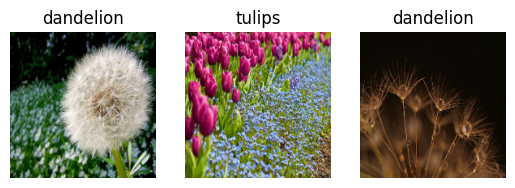

In [ ]:
import matplotlib.pyplot as plt
for image , lable in train.take(1):
  for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(image[i].numpy().astype('uint8'))
    plt.title(train.class_names[lable[i].numpy()])
    plt.axis('off')

# One hot lables

In [ ]:
train = train.map(lambda x,y : (x,keras.utils.to_categorical(y , num_classes= 5)))
validation = validation.map(lambda x,y : (x,keras.utils.to_categorical(y , num_classes= 5)))

# pipeline

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train = train.cache().prefetch(buffer_size = AUTOTUNE)
validation = validation.cache().prefetch(buffer_size = AUTOTUNE)

# Make model

In [ ]:
conv_base = InceptionResNetV2(weights='imagenet' ,include_top=False , input_shape = (180,180,3))

219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
conv_base.summary()

Model: "inception_resnet_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 180, 180,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 89, 89,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 89, 89,    │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 89, 89,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 87, 87,    │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 87, 87,    │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 87, 87,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 87, 87,    │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 87, 87,    │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 87, 87,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 43, 43,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 43, 43,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 43, 43,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 43, 43,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 41, 41,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 41, 41,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 41, 41,    │          0 │ batch_normalizat

 Total params: 54,336,736 (207.28 MB)

 Trainable params: 54,276,192 (207.05 MB)

 Non-trainable params: 60,544 (236.50 KB)

In [ ]:
model =keras.Sequential()
model.add(layers.Rescaling(1./255))
model.add(layers.RandomFlip("horizontal"))
model.add(layers.RandomRotation(0.08))
model.add(layers.RandomZoom(0.1))
model.add(layers.RandomContrast(0.1))
model.add(layers.RandomRotation(0.1))
model.add(conv_base)
model.add(layers.Flatten())
model.add(layers.Dense(512,activation='relu'))
model.add(layers.Dense(256,activation='relu'))
model.add(layers.Dense(5,activation='softmax'))

# Finetune

In [ ]:
conv_base.trainable =True
set_trainble = False
for layer in conv_base.layers:
  if layer.name == 'conv7b':
    set_trainble = True
  if set_trainble:
    layer.trainable = True
  else:
    layer.trainable = False

# compile

In [ ]:
model.compile(optimizer =tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss =keras.losses.CategoricalCrossentropy(),
              metrics =['accuracy'])

# train and test on validation

In [ ]:
model.fit(train ,validation_data= validation , epochs=45 )

Epoch 1/45
92/92 ━━━━━━━━━━━━━━━━━━━━ 49s 271ms/step - accuracy: 0.5257 - loss: 6.7832 - val_accuracy: 0.7698 - val_loss: 1.2046
Epoch 2/45
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 157ms/step - accuracy: 0.7769 - loss: 0.8196 - val_accuracy: 0.8270 - val_loss: 0.6243
Epoch 3/45
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 160ms/step - accuracy: 0.8408 - loss: 0.4650 - val_accuracy: 0.7820 - val_loss: 0.7593
Epoch 4/45
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 163ms/step - accuracy: 0.8435 - loss: 0.4822 - val_accuracy: 0.8243 - val_loss: 0.6091
Epoch 5/45
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 165ms/step - accuracy: 0.8432 - loss: 0.4706 - val_accuracy: 0.7684 - val_loss: 0.8791
Epoch 6/45
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 162ms/step - accuracy: 0.8639 - loss: 0.3937 - val_accuracy: 0.7779 - val_loss: 0.8621
Epoch 7/45
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 161ms/step - accuracy: 0.8664 - loss: 0.3819 - val_accuracy: 0.8025 - val_loss: 0.6960
Epoch 8/45
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 161ms/step - accuracy: 0.8893 - loss: 0.3158 - val_accu

# plot

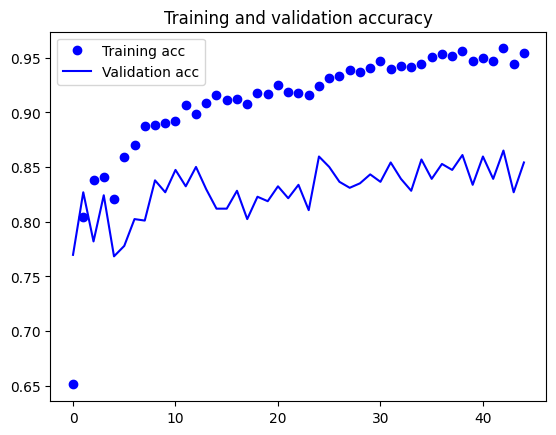

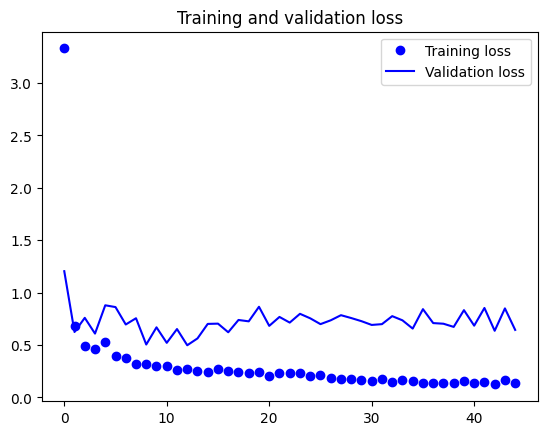

In [ ]:
acc = model.history.history['accuracy']
val_acc = model.history.history['val_accuracy']
loss = model.history.history['loss']
val_loss = model.history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

# Predict

In [ ]:
import numpy as np
class_names = ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
def predict(img):
  plt.imshow(plt.imread(img))
  img = keras.utils.load_img(img , target_size=(180,180))
  img = keras.utils.img_to_array(img)
  img = tf.expand_dims(img , 0)
  prediction = model.predict(img)
  y= np.argmax(prediction)
  plt.title(class_names[y])
  plt.axis('off')

Pleas enter URL of your photo/content/R.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


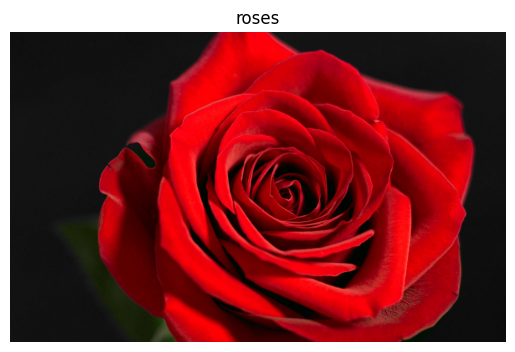

In [ ]:
img = str(input('Pleas enter URL of your photo'))
predict(img)

Pleas enter URL of your photo/content/R (1).jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step


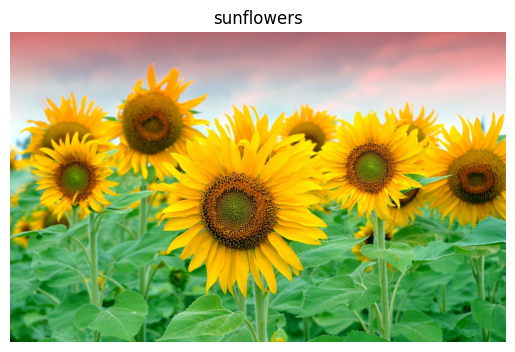

In [ ]:
img = str(input('Pleas enter URL of your photo'))
predict(img)